In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML

In [2]:
# 1) Load data
df = pd.read_csv("County_Health_Rankings.csv")

In [13]:
# 2) First look
display(df.head())
display(df.tail())
print("Shape:", df.shape)
print(df.columns.tolist())
print(df.dtypes)
print("Missing values:\n", df.isna().sum().sort_values(ascending=False))
print("Duplicate rows:", df.duplicated().sum())
display(df.describe(include="all").T)

,State,County,State code,County code,Year span,Measure name,Measure id,Numerator,Denominator,Raw value,Confidence Interval Lower Bound,Confidence Interval Upper Bound,Data Release Year,fipscode
0,US,United States,0.0,0.0,2003-2005,Violent crime rate,43.0,1328750.667,274877117.0,483.398066,NaN,NaN,NaN,0.0
1,US,United States,0.0,0.0,2004-2006,Violent crime rate,43.0,1340928.667,277612778.5,483.021233,NaN,NaN,NaN,0.0
2,US,United States,0.0,0.0,2005-2007,Violent crime rate,43.0,1355853.167,280407694.7,483.529230,NaN,NaN,2010.0,0.0
3,US,United States,0.0,0.0,2006-2008,Violent crime rate,43.0,1366928.333,287614567.7,475.263942,NaN,NaN,2011.0,0.0
4,US,United States,0.0,0.0,2007-2009,Violent crime rate,43.0,1339439.333,292576281.2,457.808585,NaN,NaN,2012.0,0.0


,State,County,State code,County code,Year span,Measure name,Measure id,Numerator,Denominator,Raw value,Confidence Interval Lower Bound,Confidence Interval Upper Bound,Data Release Year,fipscode
303859,WY,Weston County,56.0,45.0,2007,Daily fine particulate matter,125.0,NaN,NaN,9.37,NaN,NaN,NaN,56045.0
303860,WY,Weston County,56.0,45.0,2008,Daily fine particulate matter,125.0,NaN,NaN,7.45,NaN,NaN,2013.0,56045.0
303861,WY,Weston County,56.0,45.0,2009,Daily fine particulate matter,125.0,NaN,NaN,12.77,NaN,NaN,NaN,56045.0
303862,WY,Weston County,56.0,45.0,2010,Daily fine particulate matter,125.0,NaN,NaN,12.11,NaN,NaN,NaN,56045.0
303863,WY,Weston County,56.0,45.0,2011,Daily fine particulate matter,125.0,NaN,NaN,10.71,NaN,NaN,2014.0,56045.0


Shape: (303864, 14)
['State', 'County', 'State code', 'County code', 'Year span', 'Measure name', 'Measure id', 'Numerator', 'Denominator', 'Raw value', 'Confidence Interval Lower Bound', 'Confidence Interval Upper Bound', 'Data Release Year', 'fipscode']
State                               object
County                              object
State code                         float64
County code                        float64
Year span                           object
Measure name                        object
Measure id                         float64
Numerator                          float64
Denominator                        float64
Raw value                          float64
Confidence Interval Lower Bound    float64
Confidence Interval Upper Bound    float64
Data Release Year                  float64
fipscode                           float64
dtype: object
Missing values:
 Data Release Year                  153735
Denominator                        119085
Confidence Interval Lower B

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
State,303858,53,TX,24225,NaN,NaN,NaN,NaN,NaN,NaN,NaN
County,303858,2008,Washington County,2850,NaN,NaN,NaN,NaN,NaN,NaN,NaN
State code,303860.0,NaN,NaN,NaN,30.351807,15.238258,0.0,18.0,29.0,45.0,72.0
County code,303860.0,NaN,NaN,NaN,101.981422,107.824989,0.0,33.0,77.0,133.0,840.0
Year span,303390,26,2008,31927,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Measure name,303390,12,Children in poverty,41499,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Measure id,303390.0,NaN,NaN,NaN,38.699071,36.791425,1.0,7.0,24.0,50.0,125.0
Numerator,214076.0,NaN,NaN,NaN,12530.310673,351677.758749,0.0,218.0,819.0,2686.0,62144711.0
Denominator,184779.0,NaN,NaN,NaN,135401.763584,3666321.52932,10.0,2127.0,8446.022727,28220.0,602683251.0
Raw value,289956.0,NaN,NaN,NaN,1075.912013,2851.499091,0.0,0.2,0.585,91.082228,32810.4


In [14]:
# 3) Basic cleaning
df_clean = df.drop_duplicates().copy()

In [15]:
# 4) Focused analysis year
d2012 = df_clean[df_clean["Data Release Year"] == 2012.0].copy()

In [16]:
# 5) Pivot to county level
wide = d2012.pivot_table(
    index=["State", "County", "State code", "County code", "fipscode"],
    columns="Measure name",
    values="Raw value",
    aggfunc="first"
).reset_index()

In [17]:
# 6) Core stats
display(wide.describe().T)

,count,mean,std,min,25%,50%,75%,max
Measure name,,,,,,,,
State code,3193.0,30.273724,15.151292,0.000000,18.000000,29.000000,45.000000,56.000000
County code,3193.0,102.027560,107.917853,0.000000,33.000000,77.000000,133.000000,840.000000
fipscode,3193.0,30375.751331,15169.540821,0.000000,18175.000000,29177.000000,45077.000000,56045.000000
Adult obesity,3193.0,0.303567,0.041635,0.140000,0.280000,0.300000,0.330000,0.480000
Children in poverty,3189.0,0.241205,0.090202,0.027000,0.174000,0.234000,0.298000,0.611000
Diabetic screening,3130.0,0.834188,0.067645,0.150000,0.810000,0.840000,0.870000,1.000000
Mammography screening,3093.0,0.638650,0.084517,0.207000,0.588000,0.645000,0.697000,0.886000
Physical inactivity,3193.0,0.278537,0.051566,0.100000,0.250000,0.280000,0.310000,0.440000
Premature Death,3123.0,8142.098810,2397.099733,3165.466000,6459.078500,7835.446000,9493.150000,24099.540000


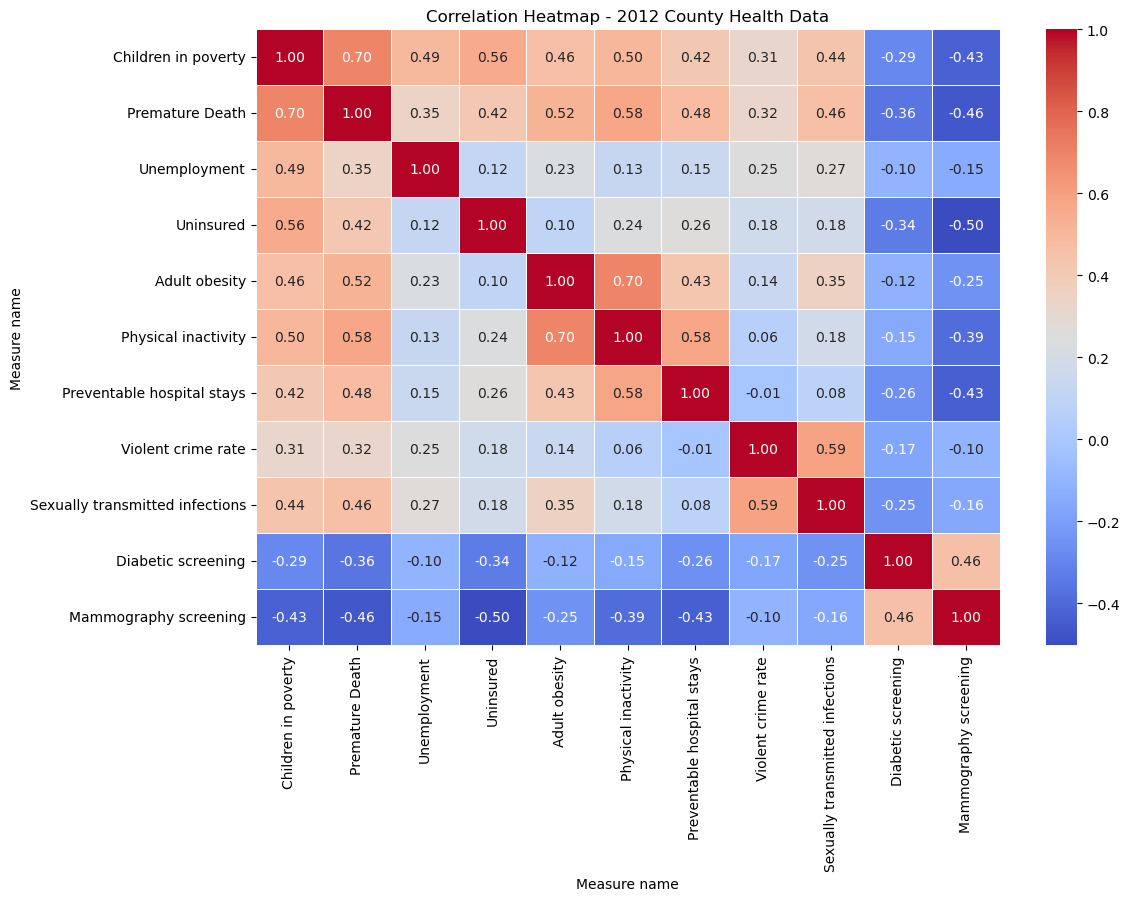

In [19]:
# 7) Correlation heatmap
corr_cols = [
    "Children in poverty", "Premature Death", "Unemployment", "Uninsured",
    "Adult obesity", "Physical inactivity", "Preventable hospital stays",
    "Violent crime rate", "Sexually transmitted infections",
    "Diabetic screening", "Mammography screening"
]
corr = wide[corr_cols].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=.5)
plt.title("Correlation Heatmap - 2012 County Health Data")
plt.show()

,count,mean,median
poverty_quartile,,,
Q1 Low,783,6173.472688,6019.840
Q2,774,7354.796032,7274.475
Q3,780,8610.202208,8520.100
Q4 High,783,10420.883808,10268.785


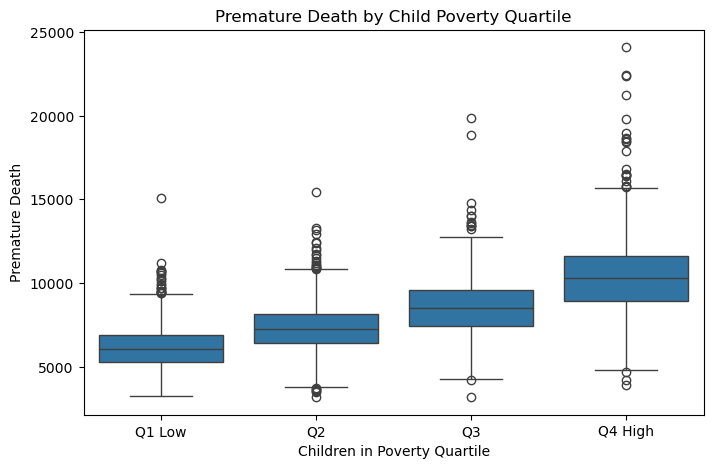

In [21]:
# 8) Main insight: poverty quartiles vs premature death
wide["poverty_quartile"] = pd.qcut(wide["Children in poverty"], 4, labels=["Q1 Low", "Q2", "Q3", "Q4 High"])
quartile_stats = wide.groupby("poverty_quartile", observed=False)["Premature Death"].agg(["count", "mean", "median"])
display(quartile_stats)

plt.figure(figsize=(8, 5))
sns.boxplot(data=wide, x="poverty_quartile", y="Premature Death")
plt.title("Premature Death by Child Poverty Quartile")
plt.xlabel("Children in Poverty Quartile")
plt.ylabel("Premature Death")
plt.show()


In [22]:
# 9) High-risk counties
top = wide[["State", "County", "Premature Death", "Children in poverty", "Unemployment", "Uninsured"]].sort_values("Premature Death", ascending=False).head(10)
display(top)

Measure name,State,County,Premature Death,Children in poverty,Unemployment,Uninsured
1823,ND,Sioux County,24099.540,0.518,0.050232,0.143
2456,SD,Shannon County,22432.583,0.489,0.124585,0.163
2461,SD,Todd County,22402.983,0.581,0.070530,0.164
2408,SD,Buffalo County,21269.701,0.475,0.154717,0.198
390,FL,Union County,19879.422,0.255,0.086860,0.266
27,AK,Yukon-Koyukuk Census Area,19817.731,0.349,0.149833,0.347
3139,WV,McDowell County,18940.989,0.454,0.108837,0.202
14,AK,Lake and Peninsula Borough,18851.256,0.253,0.080146,0.388
2415,SD,Corson County,18674.860,0.541,0.072689,0.225
2420,SD,Dewey County,18636.596,0.415,0.124287,0.214



<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="UTF-8">
<meta name="viewport" content="width=device-width, initial-scale=1.0">
<title>County Health Rankings Analysis</title>
<style>
body {font-family: Arial, Helvetica, sans-serif; line-height: 1.6; margin: 0; background: #f7f9fc; color:#1f2937;}
.container {max-width: 1100px; margin: 0 auto; padding: 32px;}
.hero {background: linear-gradient(135deg,#0f172a,#1d4ed8); color: white; padding: 36px; border-radius: 20px; box-shadow: 0 12px 30px rgba(15,23,42,.18);}
.hero h1 {margin: 0 0 8px; font-size: 2.1rem;}
.hero p {margin: 6px 0 0; opacity: .92;}
.card-grid {display:grid; grid-template-columns: repeat(auto-fit,minmax(210px,1fr)); gap:16px; margin: 22px 0;}
.card {background:#fff; border-radius:16px; padding:18px; box-shadow:0 6px 20px rgba(15,23,42,.08);}
.card h3 {margin:0 0 8px; font-size: .95rem; color:#334155;}
.card .value {font-size:1.5rem; font-weight:700; color:#0f172a;}
.section {background:#fff; border-radius:16px; padding:22px; margin-top:18px; box-shadow:0 6px 20px rgba(15,23,42,.08);}
h2 {margin-top:0; color:#0f172a;}
table {width:100%; border-collapse: collapse;}
th, td {border-bottom:1px solid #e5e7eb; padding:10px 8px; text-align:left; vertical-align:top;}
th {background:#f8fafc;}
.code {background:#0b1020; color:#e5e7eb; padding:14px; border-radius:12px; overflow:auto;}
.small {color:#475569; font-size:.95rem;}
</style>
</head>
<body>
<div class="container">
  <div class="hero">
    <h1>County Health Rankings CSV Analysis</h1>
    <p>End-to-end exploratory data analysis for GitHub and Microsoft Word presentation</p>
    <p><strong>Primary focus:</strong> county child poverty and its relationship with premature death</p>
  </div>

  <div class="card-grid">
    <div class="card"><h3>Rows</h3><div class="value">303864</div></div><div class="card"><h3>Columns</h3><div class="value">14</div></div><div class="card"><h3>Exact duplicate rows</h3><div class="value">6793</div></div><div class="card"><h3>Duplicate share</h3><div class="value">2.24%</div></div><div class="card"><h3>Unique states / territories</h3><div class="value">53</div></div><div class="card"><h3>Unique county names</h3><div class="value">2008</div></div><div class="card"><h3>Unique FIPS codes</h3><div class="value">3275</div></div>
  </div>

  <div class="section">
    <h2>Dataset overview</h2>
    <p class="small">The raw dataset contains 303,864 rows and 14 columns. It includes state/county identifiers, year spans, 12 measures, and health outcome values. Exact duplicate rows account for 2.24% of the file and should be removed before final reporting.</p>
  </div>

  <div class="section">
    <h2>Why 2012 is used for the main analysis</h2>
    <p class="small">The 2012 release year is the best single-year slice for analysis because it contains 3,193 county rows and all 11 key measures with only small gaps. That allows a clean county-level pivot for correlation and comparison work.</p>
  </div>

  <div class="section">
    <h2>Key metrics</h2>
    <table border="1" class="dataframe">
  <thead>
    <tr style="text-align: right;">
      <th>Metric</th>
      <th>Value</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td>2012 county rows</td>
      <td>35115</td>
    </tr>
    <tr>
      <td>Measures in 2012</td>
      <td>11</td>
    </tr>
    <tr>
      <td>Missing values in 2012 pivot</td>
      <td>616</td>
    </tr>
    <tr>
      <td>Premature Death mean</td>
      <td>8142.10</td>
    </tr>
    <tr>
      <td>Premature Death median</td>
      <td>7835.45</td>
    </tr>
    <tr>
      <td>Children in poverty mean</td>
      <td>0.241</td>
    </tr>
    <tr>
      <td>Children in poverty median</td>
      <td>0.234</td>
    </tr>
    <tr>
      <td>Premature Death correlation with Children in poverty</td>
      <td>0.699</td>
    </tr>
    <tr>
      <td>Premature Death correlation with Uninsured</td>
      <td>0.419</td>
    </tr>
    <tr>
      <td>Premature Death correlation with Physical inactivity</td>
      <td>0.575</td>
    </tr>
    <tr>
      <td>Premature Death correlation with Adult obesity</td>
      <td>0.519</td>
    </tr>
  </tbody>
</table>
  </div>

  <div class="section">
    <h2>Most important finding</h2>
    <p class="small">Counties with higher child poverty also have much higher premature death. The correlation between <strong>Children in poverty</strong> and <strong>Premature Death</strong> is <strong>0.699</strong>. This is the strongest positive relationship in the main county-level analysis.</p>
    <p class="small">When counties are grouped by child poverty quartile, the mean premature death rate rises from <strong>6173.47</strong> in the lowest poverty quartile to <strong>10420.88</strong> in the highest poverty quartile — a gap of about <strong>4247.41</strong>, or <strong>68.8%</strong>.</p>
  </div>

  <div class="section">
    <h2>High-risk counties</h2>
    <table border="1" class="dataframe">
  <thead>
    <tr style="text-align: right;">
      <th>Measure name</th>
      <th>State</th>
      <th>County</th>
      <th>Premature Death</th>
      <th>Children in poverty</th>
      <th>Unemployment</th>
      <th>Uninsured</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th></th>
      <td>ND</td>
      <td>Sioux County</td>
      <td>24099.540</td>
      <td>0.518</td>
      <td>0.050232</td>
      <td>0.143</td>
    </tr>
    <tr>
      <th></th>
      <td>SD</td>
      <td>Shannon County</td>
      <td>22432.583</td>
      <td>0.489</td>
      <td>0.124585</td>
      <td>0.163</td>
    </tr>
    <tr>
      <th></th>
      <td>SD</td>
      <td>Todd County</td>
      <td>22402.983</td>
      <td>0.581</td>
      <td>0.070530</td>
      <td>0.164</td>
    </tr>
    <tr>
      <th></th>
      <td>SD</td>
      <td>Buffalo County</td>
      <td>21269.701</td>
      <td>0.475</td>
      <td>0.154717</td>
      <td>0.198</td>
    </tr>
    <tr>
      <th></th>
      <td>FL</td>
      <td>Union County</td>
      <td>19879.422</td>
      <td>0.255</td>
      <td>0.086860</td>
      <td>0.266</td>
    </tr>
    <tr>
      <th></th>
      <td>AK</td>
      <td>Yukon-Koyukuk Census Area</td>
      <td>19817.731</td>
      <td>0.349</td>
      <td>0.149833</td>
      <td>0.347</td>
    </tr>
    <tr>
      <th></th>
      <td>WV</td>
      <td>McDowell County</td>
      <td>18940.989</td>
      <td>0.454</td>
      <td>0.108837</td>
      <td>0.202</td>
    </tr>
    <tr>
      <th></th>
      <td>AK</td>
      <td>Lake and Peninsula Borough</td>
      <td>18851.256</td>
      <td>0.253</td>
      <td>0.080146</td>
      <td>0.388</td>
    </tr>
    <tr>
      <th></th>
      <td>SD</td>
      <td>Corson County</td>
      <td>18674.860</td>
      <td>0.541</td>
      <td>0.072689</td>
      <td>0.225</td>
    </tr>
    <tr>
      <th></th>
      <td>SD</td>
      <td>Dewey County</td>
      <td>18636.596</td>
      <td>0.415</td>
      <td>0.124287</td>
      <td>0.214</td>
    </tr>
  </tbody>
</table>
  </div>

  <div class="section">
    <h2>Recommended solution</h2>
    <p class="small">Focus on high-poverty counties with a package of interventions: expand preventive care access, reduce uninsured rates, support nutrition and activity programs, and target economic support for families with children. The data suggests that health and social outcomes move together, so the solution should be multi-sector rather than medical-only.</p>
  </div>
</div>
</body>
</html>
